In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
plt.rcParams["figure.figsize"] = (8, 4)
sns.set_theme(style="whitegrid")

In [3]:
data_path = Path("../data/processed/student_performance.csv")

In [4]:
df = pd.read_csv(data_path)
df.head()

,student_id,day,topic,exercises_attempted,exercises_solved_correctly,hints_used,time_spent_minutes,previous_eval_score,today_eval_score,at_risk
0,1,1,variables,4,3,8,35,12.91,16.18,False
1,1,2,conditions,3,0,6,31,16.18,6.49,True
2,1,3,loops,5,4,4,117,6.49,11.26,False
3,1,4,lists,5,2,0,64,11.26,12.59,False
4,1,5,functions,3,0,7,65,12.59,2.45,True


In [5]:
print("Shape: ", df.shape)

print("\nColumns :")
print(df.columns.tolist())

print("\nData types: ")
print(df.dtypes)

Shape:  (264, 10)

Columns :
['student_id', 'day', 'topic', 'exercises_attempted', 'exercises_solved_correctly', 'hints_used', 'time_spent_minutes', 'previous_eval_score', 'today_eval_score', 'at_risk']

Data types: 
student_id                      int64
day                             int64
topic                          object
exercises_attempted             int64
exercises_solved_correctly      int64
hints_used                      int64
time_spent_minutes              int64
previous_eval_score           float64
today_eval_score              float64
at_risk                          bool
dtype: object


In [6]:
# assert df.shape == (480,10), f"Unexpected shape:{df.shape}"
# assert df["student_id"].nunique() == 24
# assert df["day"].nunique() == 20

In [7]:
df.isnull().sum()

student_id                    0
day                           0
topic                         0
exercises_attempted           0
exercises_solved_correctly    0
hints_used                    0
time_spent_minutes            0
previous_eval_score           0
today_eval_score              0
at_risk                       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.duplicated(subset=["student_id","day"]).sum()

0

In [10]:
print(df["today_eval_score"].min(), df["today_eval_score"].max())
print(df["hints_used"].min(), df["hints_used"].max())
print(df["exercises_attempted"].min(), df["exercises_attempted"].max())

0.0 20.0
0 10
1 5


In [11]:
invalid = df["exercises_solved_correctly"] > df["exercises_attempted"]
print("Invalid rows:",invalid.sum())

Invalid rows: 0


In [12]:
df.describe(include="all")

,student_id,day,topic,exercises_attempted,exercises_solved_correctly,hints_used,time_spent_minutes,previous_eval_score,today_eval_score,at_risk
count,264.000000,264.000000,264,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264
unique,NaN,NaN,11,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,variables,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,142
mean,12.500000,6.000000,NaN,3.102273,1.503788,5.215909,67.537879,9.513826,9.209811,NaN
std,6.935334,3.168284,NaN,1.365293,1.446112,3.291129,30.358543,5.602067,5.760083,NaN
min,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,15.000000,0.000000,0.000000,NaN
25%,6.750000,3.000000,NaN,2.000000,0.000000,2.000000,40.000000,5.105000,4.677500,NaN
50%,12.500000,6.000000,NaN,3.000000,1.000000,5.000000,68.000000,9.750000,8.995000,NaN
75%,18.250000,9.000000,NaN,4.000000,2.250000,8.000000,96.000000,14.235000,13.895000,NaN


In [13]:
score = df["today_eval_score"]

print("mean: ", score.mean())
print("std: ", score.std())
print("min: ",score.min())
print("max: ",score.max())

mean:  9.209810606060605
std:  5.760083402216972
min:  0.0
max:  20.0


In [14]:
skew_val = stats.skew(score)
print(f"Skewness: {skew_val:.2f}")

Skewness: 0.03


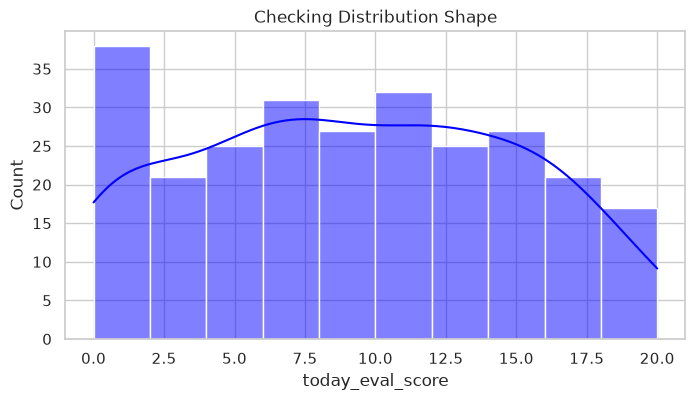

In [15]:
sns.histplot(score, kde=True, color='blue')
plt.title("Checking Distribution Shape")
plt.show()

In [16]:
print(df["at_risk"].value_counts())
print()
print(df["at_risk"].value_counts(normalize=True)*100)

mismatch = df["at_risk"] != (df["today_eval_score"] < 10)
print("Definition mismatches: ",mismatch.sum())

at_risk
True     142
False    122
Name: count, dtype: int64

at_risk
True     53.787879
False    46.212121
Name: proportion, dtype: float64
Definition mismatches:  0


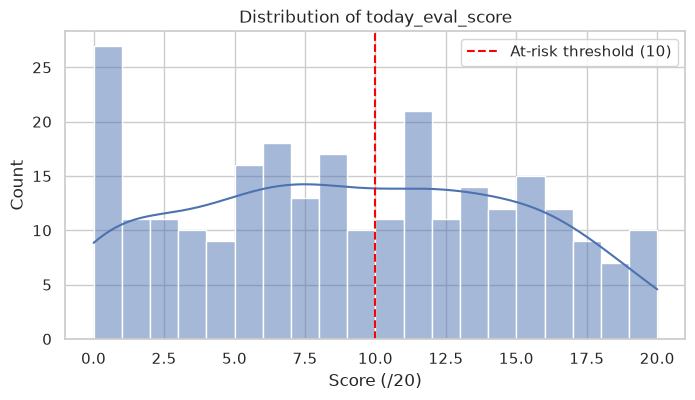

In [17]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="today_eval_score", bins=20, kde=True, ax=ax)
ax.axvline(10, color="red", linestyle="--", label="At-risk threshold (10)")
ax.set_title("Distribution of today_eval_score")
ax.set_xlabel("Score (/20)")
ax.legend()
plt.show()

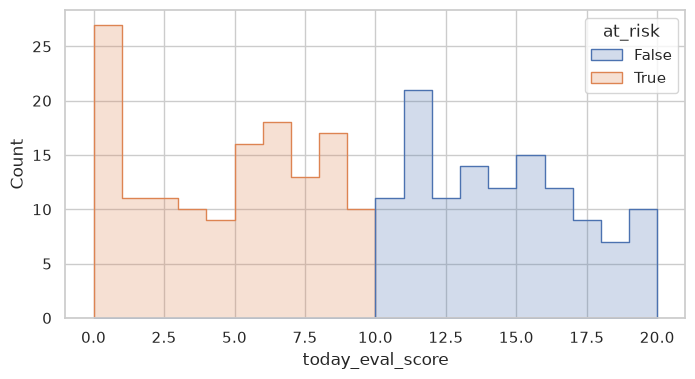

In [18]:
sns.histplot(data=df, x="today_eval_score", hue="at_risk", bins=20, element="step")
plt.show()

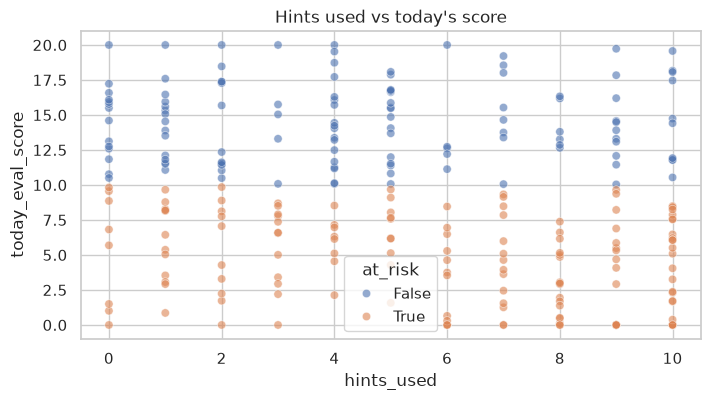

In [19]:
sns.scatterplot(
    data=df,
    x="hints_used",
    y="today_eval_score",
    hue="at_risk",
    alpha=0.6,
)
plt.title("Hints used vs today's score")
plt.show()

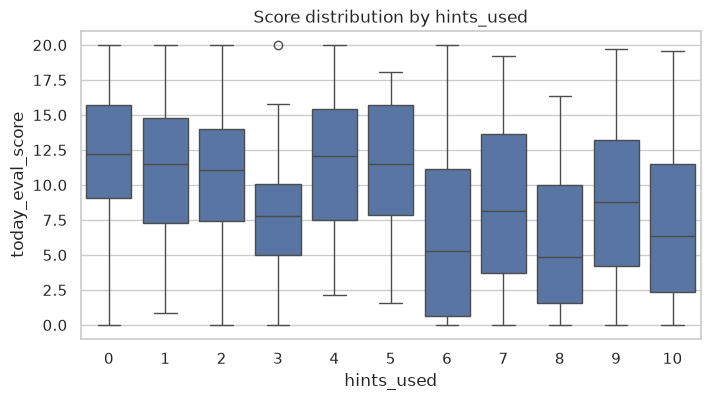

In [20]:
sns.boxplot(data=df, x="hints_used", y="today_eval_score")
plt.title("Score distribution by hints_used")
plt.show()

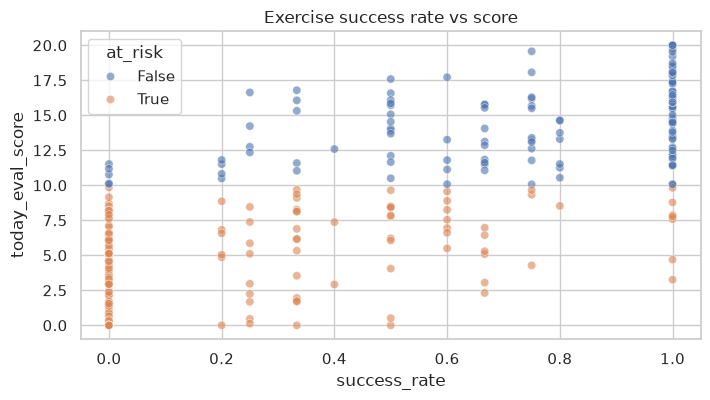

In [21]:
df = df.copy()
df["success_rate"] = df["exercises_solved_correctly"] / df["exercises_attempted"]

sns.scatterplot(data=df, x="success_rate", y="today_eval_score", hue="at_risk", alpha=0.6)
plt.title("Exercise success rate vs score")
plt.show()

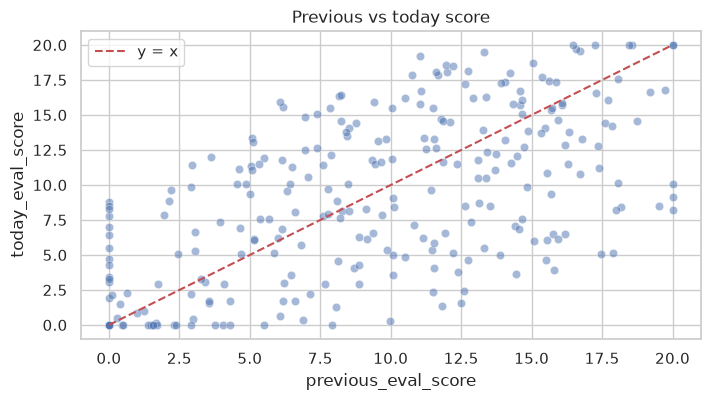

In [22]:
sns.scatterplot(
    data=df,
    x="previous_eval_score",
    y="today_eval_score",
    alpha=0.5,
)
plt.plot([0, 20], [0, 20], "r--", label="y = x")
plt.legend()
plt.title("Previous vs today score")
plt.show()

In [23]:
numeric_cols = [
    "day",
    "exercises_attempted",
    "exercises_solved_correctly",
    "hints_used",
    "time_spent_minutes",
    "previous_eval_score",
    "today_eval_score",
    "success_rate", 
]

corr = df[numeric_cols].corr(method="pearson")
corr

,day,exercises_attempted,exercises_solved_correctly,hints_used,time_spent_minutes,previous_eval_score,today_eval_score,success_rate
day,1.000000,-0.067684,-0.055602,0.084599,0.016168,-0.206150,-0.150495,-0.000103
exercises_attempted,-0.067684,1.000000,0.541922,-0.051474,-0.047659,-0.031246,0.140235,0.096083
exercises_solved_correctly,-0.055602,0.541922,1.000000,0.003423,0.009221,0.029433,0.625500,0.793364
hints_used,0.084599,-0.051474,0.003423,1.000000,-0.021793,-0.077317,-0.242076,0.008955
time_spent_minutes,0.016168,-0.047659,0.009221,-0.021793,1.000000,-0.001325,0.046453,0.039141
previous_eval_score,-0.206150,-0.031246,0.029433,-0.077317,-0.001325,1.000000,0.584671,0.044252
today_eval_score,-0.150495,0.140235,0.625500,-0.242076,0.046453,0.584671,1.000000,0.722306
success_rate,-0.000103,0.096083,0.793364,0.008955,0.039141,0.044252,0.722306,1.000000


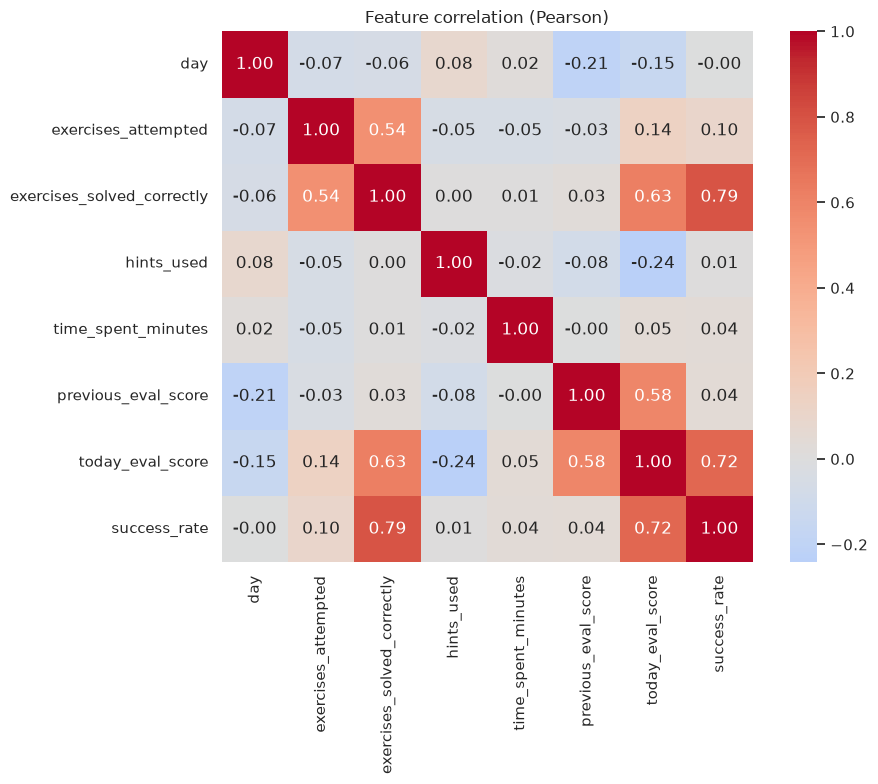

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,      # write numbers in cells
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Feature correlation (Pearson)")
plt.tight_layout()
plt.show()

In [25]:
corr["today_eval_score"].sort_values(ascending=False)

today_eval_score              1.000000
success_rate                  0.722306
exercises_solved_correctly    0.625500
previous_eval_score           0.584671
exercises_attempted           0.140235
time_spent_minutes            0.046453
day                          -0.150495
hints_used                   -0.242076
Name: today_eval_score, dtype: float64

              topic  today_eval_score
0         variables         11.533750
1        conditions          9.963750
2             loops         10.162083
3             lists          9.949167
4         functions          8.518333
5      dictionaries          9.006667
6       oop_classes          9.033333
7   oop_inheritance          7.839583
8    error_handling          8.186250
9             files          8.516250
10    final_project          8.598750


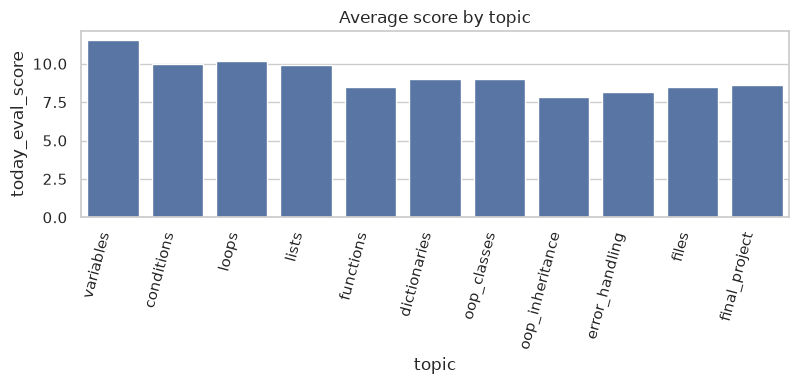

In [26]:
topic_scores = (
    df.groupby("topic", sort=False)["today_eval_score"]
    .mean()
    .reset_index()
)
print(topic_scores)
sns.barplot(data=topic_scores, x="topic", y="today_eval_score")
plt.xticks(rotation=75, ha="right")
plt.title("Average score by topic")
plt.tight_layout()
plt.show()

In [27]:
risk_by_student = (
    df.groupby("student_id")["at_risk"]
    .mean()
    .sort_values(ascending=False)
)
risk_by_student.head(10) 

student_id
16    0.909091
22    0.909091
8     0.909091
23    0.818182
4     0.818182
6     0.818182
24    0.727273
2     0.727273
11    0.636364
12    0.636364
Name: at_risk, dtype: float64

In [28]:
struggling = (df["exercises_solved_correctly"] < 3) & (df["hints_used"] > 5)
print("Rows matching penalty rule:", struggling.sum())
print("Mean score (penalty group):", df.loc[struggling, "today_eval_score"].mean())
print("Mean score (others):", df.loc[~struggling, "today_eval_score"].mean())

Rows matching penalty rule: 87
Mean score (penalty group): 4.745977011494253
Mean score (others): 11.403898305084747


## Insights (Phase 1)

1. **Shape & quality:** The dataset has 264 rows and 10 columns. Missing values: 0. Duplicates: 0.
2. **Score distribution:** Mean ≈ 9.21 , std ≈ 5.76 . Scores fairly symmetric.
3. **At-risk balance:** 53.79 % of rows are at-risk (`score < 10`). This is balanced  for classification.
4. **Strongest correlates with `today_eval_score`:** 
1) success_rate   
2) exercises_solved_correctly 
3) previous_eval_score 

5. **Hints effect:** Higher `hints_used` tends to lower  scores — visible in [scatter/boxplot].

6. **Generator check:** Penalty group (solved < 3 & hints > 5) mean score = 4.75 vs others = 11.4 .

7. **Persistence:** `previous_eval_score` is strongly related to today — matches the 0.6 weight in the formula.

8. **Implication for Phase 2:** I expect Random Forest to rely most on success_rate, exercises_solved_correctly, and previous_eval_score. Watch Recall because because the coach needs to catch failing students (~54% at-risk).

### One-sentence summary
Students who solve few exercises while using many hints are most at risk because of the −4 penalty and low success rate.